# Modelagem

Nesse notebook iremos testar diversas abordagens de modelagem e iremos escolher a que performar melhor no nosso dataset.

## Importando as Bibliotecas

Primeiro, vamos importar nossas bibliotecas.

In [1]:
import numpy as np
import pandas as pd

## Carregando o Dataset

Agora, vamos carregar o dataset.

In [2]:
df = pd.read_parquet("../data/processed/03_processed.parquet")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7919 entries, 0 to 7918
Data columns (total 61 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   tipo_imovel                            7919 non-null   category
 1   preco                                  7919 non-null   Int64   
 2   condominio                             4602 non-null   Int64   
 3   area_m2                                7919 non-null   Int64   
 4   quartos                                7918 non-null   Int64   
 5   banheiros                              7918 non-null   Int64   
 6   vagas                                  7286 non-null   Int64   
 7   piscina                                7919 non-null   boolean 
 8   espaco_gourmet                         7919 non-null   boolean 
 9   academia                               7919 non-null   boolean 
 10  spa_massagem                           7919 non-null   boolean 
 11  es

In [205]:
df.head(10)

,tipo_imovel,preco,condominio,area_m2,quartos,banheiros,vagas,piscina,espaco_gourmet,academia,...,m2_por_banheiro,m2_por_quarto,banheiros_por_m2,quartos_por_m2,banheiro_por_quarto,quarto_por_vaga,vaga_por_banheiro,area_m2_log,condominio_log,cluster
0,apartamento,350000,720,60,2,2,1,True,True,True,...,30.000000,30.000000,0.033333,0.033333,1.000000,2.00,0.500000,4.110874,6.580639,4
1,apartamento,511914,<NA>,37,1,1,1,True,True,True,...,37.000000,37.000000,0.027027,0.027027,1.000000,1.00,1.000000,3.637586,NaN,1
2,apartamento,980000,1037,125,3,5,2,True,True,False,...,25.000000,41.666667,0.040000,0.024000,1.666667,1.50,0.400000,4.836282,6.945051,1
3,apartamento,2799000,1200,244,3,4,4,True,True,True,...,61.000000,81.333333,0.016393,0.012295,1.333333,0.75,1.000000,5.501258,7.090910,14
4,apartamento,370000,460,57,2,2,1,True,True,True,...,28.500000,28.500000,0.035088,0.035088,1.000000,2.00,0.500000,4.060443,6.133398,11
5,apartamento,499000,<NA>,55,2,2,1,True,True,True,...,27.500000,27.500000,0.036364,0.036364,1.000000,2.00,0.500000,4.025352,NaN,7
6,apartamento,195000,350,52,1,1,<NA>,True,True,True,...,52.000000,52.000000,0.019231,0.019231,1.000000,NaN,NaN,3.970292,5.860786,8
7,apartamento,1210314,<NA>,128,3,3,2,True,True,True,...,42.666667,42.666667,0.023438,0.023438,1.000000,1.50,0.666667,4.859812,NaN,1
8,apartamento,860000,880,105,3,4,2,True,True,True,...,26.250000,35.000000,0.038095,0.028571,1.333333,1.50,0.500000,4.663439,6.781058,1
9,apartamento,400000,400,55,2,2,1,True,True,True,...,27.500000,27.500000,0.036364,0.036364,1.000000,2.00,0.500000,4.025352,5.993961,7


## Divisão Treino-Teste

Nessa etapa de modelagem faremos otimização de hiperparâmetros dos nossos modelos e para checarmos a qualidade final do modelo iremos testâ-lo em dados de teste. Para isso precisamos dividir os dados de treinamento e de teste.

In [173]:
from sklearn.model_selection import train_test_split

X = df.drop("preco", axis="columns")
y = df["preco"]

random_state = 1667

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.7,
    random_state=random_state,
)

## Regressão Linear com Regularização L1 (Lasso)

O primeiro modelo que iremos treinar é o modelo de Regressão Linear com Regularização L1, também conhecida como Lasso, sendo esse modelo o nosso baseline. Faremos a otimização de hiperparâmetros desse modelo usando a Validação Cruzada com 5 folds e usando a biblioteca `Optuna`.

In [186]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
)
from sklearn.compose import (
    ColumnTransformer,
    TransformedTargetRegressor,
)
from sklearn.model_selection import (
    KFold,
    cross_val_score,
    cross_validate,
)
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from feature_engine.outliers import Winsorizer

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=random_state,
)

discrete_columns = ["quartos", "banheiros", "vagas"]
continuous_columns = (X_train
    .drop(discrete_columns, axis="columns")
    .select_dtypes(include=["int", "float"])
    .columns
    .to_list()
)

ordinal_columns = ["faixa_area", "faixa_condominio"]
categorical_columns = (X_train
    .drop(ordinal_columns, axis="columns")
    .select_dtypes(include="category")
    .columns
    .to_list()
)

def get_elastic_net_pipeline(parameters):
    continuous_pipeline = Pipeline(steps=[
        ("clip", Winsorizer(
            capping_method="quantiles",
            tail="right",
            fold=0.01,
            missing_values="ignore",
            variables=["condominio", "area_m2"],
        )),
        ("imputer", SimpleImputer(strategy="median")),
        # ("scaler", RobustScaler()),
    ])

    discrete_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("poly", PolynomialFeatures(include_bias=False)),
        # ("scaler", RobustScaler()),
    ])

    categorical_pipeline = Pipeline(steps=[
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        )),
    ])

    ordinal_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder()),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("continuous", continuous_pipeline, continuous_columns),
            # ("discrete", discrete_pipeline, discrete_columns),
            # ("categorical", categorical_pipeline, categorical_columns),
            # ("ordinal", ordinal_pipeline, ordinal_columns),
        ],
        remainder="drop",
    )

    regressor = Ridge(
        alpha=parameters["alpha"],
        # l1_ratio=parameters["l1_ratio"],
        max_iter=10000,
        random_state=random_state,
    )

    transformer = QuantileTransformer(
        output_distribution="normal"
    )

    model = TransformedTargetRegressor(
        regressor=regressor,
        transformer=transformer,
    )

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    return pipeline


def objective_elastic_net(trial):
    pipeline = get_elastic_net_pipeline({
        "alpha": trial.suggest_float("alpha", 1e-4, 1.0, log=True),
        # "l1_ratio": trial.suggest_float("l1_ratio", 0.01, 0.99),
    })

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=kfold,
        scoring="neg_mean_absolute_error",
    )

    return scores.mean()

Agora que montamos nossa função objetivo, vamos criar nosso estudo e executar a otimização de hiperparâmetros.

In [187]:
import optuna

study = optuna.create_study(
    direction="maximize",
)

study.optimize(
    objective_elastic_net,
    n_trials=10,
    show_progress_bar=True,
)

[I 2026-08-21 01:51:21,056] A new study created in memory with name: no-name-d9b09772-dd28-47e1-ac10-39433e79be61
Best trial: 0. Best value: -363592:  20%|██        | 2/10 [00:00<00:01,  5.43it/s]

[I 2026-08-21 01:51:21,250] Trial 0 finished with value: -363591.9479453561 and parameters: {'alpha': 0.046298921592357455}. Best is trial 0 with value: -363591.9479453561.
[I 2026-08-21 01:51:21,429] Trial 1 finished with value: -363631.63969894906 and parameters: {'alpha': 0.00012328962825281688}. Best is trial 0 with value: -363591.9479453561.


Best trial: 3. Best value: -363328:  40%|████      | 4/10 [00:00<00:01,  5.41it/s]

[I 2026-08-21 01:51:21,616] Trial 2 finished with value: -363521.2889108048 and parameters: {'alpha': 0.0008638243283103909}. Best is trial 2 with value: -363521.2889108048.
[I 2026-08-21 01:51:21,800] Trial 3 finished with value: -363328.17056343035 and parameters: {'alpha': 0.003115104529031915}. Best is trial 3 with value: -363328.17056343035.


Best trial: 3. Best value: -363328:  60%|██████    | 6/10 [00:01<00:00,  5.37it/s]

[I 2026-08-21 01:51:21,991] Trial 4 finished with value: -363597.12657647475 and parameters: {'alpha': 0.0003565131208486769}. Best is trial 3 with value: -363328.17056343035.
[I 2026-08-21 01:51:22,176] Trial 5 finished with value: -364260.232260515 and parameters: {'alpha': 0.11504524568065289}. Best is trial 3 with value: -363328.17056343035.


Best trial: 3. Best value: -363328:  80%|████████  | 8/10 [00:01<00:00,  5.44it/s]

[I 2026-08-21 01:51:22,363] Trial 6 finished with value: -363390.17428355676 and parameters: {'alpha': 0.0023775110645753374}. Best is trial 3 with value: -363328.17056343035.
[I 2026-08-21 01:51:22,541] Trial 7 finished with value: -366072.5369189773 and parameters: {'alpha': 0.7283009068546532}. Best is trial 3 with value: -363328.17056343035.


Best trial: 3. Best value: -363328: 100%|██████████| 10/10 [00:01<00:00,  5.47it/s]

[I 2026-08-21 01:51:22,714] Trial 8 finished with value: -364396.31376225414 and parameters: {'alpha': 0.13801928922038162}. Best is trial 3 with value: -363328.17056343035.
[I 2026-08-21 01:51:22,886] Trial 9 finished with value: -363578.8005120944 and parameters: {'alpha': 0.00047751835261808216}. Best is trial 3 with value: -363328.17056343035.


In [188]:
print(f"Best R^2: {study.best_value}")

Best R^2: -363328.17056343035


In [189]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_absolute_percentage_error,
)

pipeline = get_elastic_net_pipeline(study.best_params)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("========== Lasso Metrics ==========")
print(f"R^2:  {r2_score(y_test, y_pred)}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred)}")

========== Lasso Metrics ==========
R^2:  0.5381172369151144
MAE:  398549.04152190266
RMSE: 1060205.6761210298
MAPE: 0.29842961863326356


In [190]:
(y_test - y_pred).mean()

np.float64(120009.68628345832)

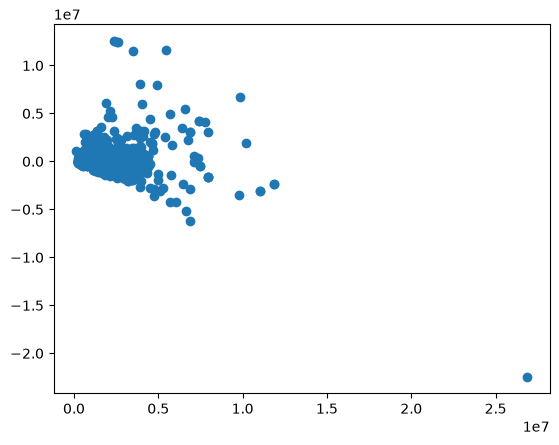

In [191]:
import matplotlib.pyplot as plt

plt.scatter(x=y_pred, y=(y_test-y_pred))
plt.show()

In [200]:
opa = X_test.iloc[2100:2101].copy()
print(opa.to_string())

print(pipeline.predict(pd.DataFrame(opa)))

     tipo_imovel  condominio  area_m2  quartos  banheiros  vagas piscina espaco_gourmet academia spa_massagem espaco_lazer area_trabalho espaco_infantil area_esportiva portaria seguranca servicos_garagem acessibilidade   pets varanda area_verde espaco_natural acabamento_premium moveis_embutidos layout_premium cozinha servicos conforto_interno mobiliado casa_inteligente servicos_conectividade infra_energetica infra_hidrica servicos_sustentaveis   latitude  longitude  distancia_lago_das_rosas_km  distancia_vaca_brava_km  distancia_parque_areiao_km  distancia_parque_flamboyant_km  distancia_bosque_dos_buritis_km  distancia_flamboyant_shopping_km  distancia_goiania_shopping_km  distancia_passeio_das_aguas_km  distancia_shopping_cerrado_km  distancia_buriti_shopping_km  distancia_hospital_albert_einstein_km  distancia_hospital_mater_dei_km  distancia_hospital_anis_rassi_km  distancia_hospital_jacob_facuri_km  distancia_hugol_km  distancia_crer_km  distancia_hgg_km  distancia_ufg_samambaia_k

In [201]:
pipeline.named_steps["model"].regressor_.coef_

array([-4.11049014e-06,  5.15548781e-04,  5.15569217e+00,  3.54481081e+00,
        5.59937996e-01, -1.25155214e+00,  9.07060330e-02,  7.27857234e-02,
       -9.31013233e-01,  6.63068045e-02,  9.57229796e-01, -4.10754279e-02,
       -2.19944445e-02, -4.10143693e-02, -2.07398486e-01,  2.22191237e-01,
       -7.51628311e-01,  3.77257176e-02,  3.58527270e-03,  2.23129509e-01,
        4.32161788e-01,  1.76789672e-01,  1.27559185e+00, -8.69644027e-01,
       -1.16956934e+00,  1.12199350e+00,  1.02970352e+00, -6.74030173e-01,
       -2.46324135e-01, -2.05982045e-01,  1.52530748e-01, -6.50915925e-03,
        4.23888817e-03,  1.50819332e+01, -6.15510183e+00, -1.77184272e-01,
       -7.12130992e-02,  1.09113956e-01,  1.13867847e+00,  2.77188506e-02])

(array([ 40., 838., 625., 257., 231., 119.,  54.,  43.,   6.,  24.,  10.,
          8.,   7.,   9.,  12.,   9.,   5.,   6.,   4.,   0.,   2.,   0.,
          2.,   3.,   1.,   2.,   0.,   1.,   1.,   1.,   0.,   0.,   0.,
          0.,   0.,   0.,   1.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   1.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         51.]),
 array([   49000.,   318510.,   588020.,   857530.,  1127040.,  1396550.,
         1666060.,  1935570.,  2205080.,  2474590.,  2744100.,  3013610.,
         3283120.,  3552630.,  3822140.,  4091650.,  4361160.,  4630670.,
         4900180.,  5169690.,  5439200.,  5708710.,  5978220.,  6247730.,
         6517240.,  67

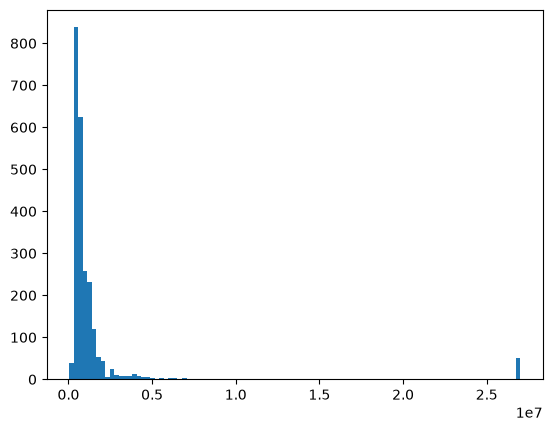

In [153]:
plt.hist(y_pred, bins=100)

(array([ 20., 241., 419., 417., 272., 150., 119., 113., 100.,  60.,  70.,
         50.,  40.,  16.,  25.,  13.,  28.,  12.,  16.,  18.,  25.,   9.,
         18.,   8.,  11.,  16.,   9.,   6.,   3.,   8.,   3.,   4.,   7.,
          1.,   1.,   0.,   5.,   0.,   1.,   1.,   1.,   3.,   1.,   5.,
          1.,   0.,   3.,   1.,   0.,   3.,   1.,   1.,   4.,   1.,   0.,
          0.,   0.,   0.,   0.,   3.,   0.,   0.,   0.,   0.,   0.,   2.,
          2.,   0.,   0.,   1.,   0.,   1.,   0.,   1.,   0.,   0.,   0.,
          1.,   0.,   1.,   1.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          2.]),
 array([   68000.,   217320.,   366640.,   515960.,   665280.,   814600.,
          963920.,  1113240.,  1262560.,  1411880.,  1561200.,  1710520.,
         1859840.,  2009160.,  2158480.,  2307800.,  2457120.,  2606440.,
         2755760.,  2905080.,  3054400.,  3203720.,  3353040.,  3502360.,
         3651680.,  38

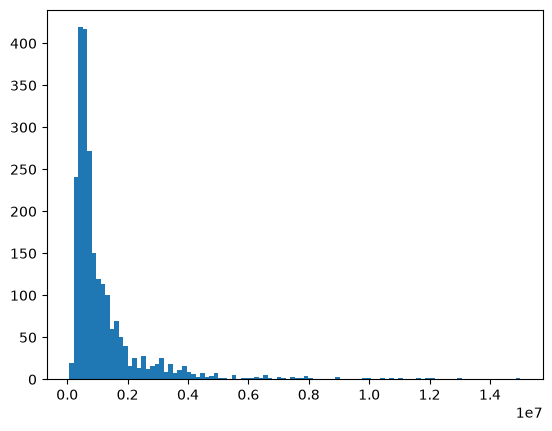

In [154]:
plt.hist(y_test, bins=100)

In [156]:
pipeline.named_steps["model"].regressor_.coef_

array([-7.86024037e-06,  3.55167813e-05,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -0.00000000e+00, -0.00000000e+00,  1.69102087e-02,
       -0.00000000e+00, -0.00000000e+00, -7.32930454e-03,  0.00000000e+00,
        0.00000000e+00,  5.75855596e-03, -3.67916842e-02,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  3.27686416e-03,  0.00000000e+00,
        0.00000000e+00, -1.67709478e-03,  0.00000000e+00,  0.00000000e+00,
        1.46584429e-03,  6.19717516e-05, -0.00000000e+00, -0.00000000e+00,
       -2.11507631e-03, -0.00000000e+00,  1.63218657e-02,  7.52965398e-05,
       -2.09730224e-04, -0.00000000e+00, -0.00000000e+00,  0.00000000e+00,
       -3.17222488e-02,  0.00000000e+00,  1.31998426e-01,  2.38033046e-03,
        0.00000000e+00,  1.06876741e-01,  0.00000000e+00, -0.00000000e+00,
       -2.27186934e-03,  9.83234174e-03, -4.60010985e-03, -9.76592028e-04,
       -8.86404534e-04, -1.90852937e-02, -0.00000000e+00,  0.00000000e+00,
       -0.00000000e+00, -

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop("preco", axis="columns")
y = df["preco"]

random_state = 1667

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.7,
    random_state=random_state,
)

In [24]:
from sklearn.model_selection import (
    KFold,
    cross_val_score,
)
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from feature_engine.outliers import Winsorizer

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=random_state,
)

ordinal_columns = ["faixa_area", "faixa_condominio"]
numeric_columns = (X_train
    .select_dtypes(include="number")
    .columns
    .to_list()
)
categorical_columns = (X_train
    .drop(ordinal_columns, axis="columns")
    .select_dtypes(include="category")
    .columns
    .to_list()
)

def get_xgboost_pipeline(parameters):
    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])

    categorical_pipeline = Pipeline(steps=[
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        )),
    ])

    ordinal_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder()),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_columns),
            # ("discrete", discrete_pipeline, discrete_columns),
            # ("categorical", categorical_pipeline, categorical_columns),
            # ("ordinal", ordinal_pipeline, ordinal_columns),
        ],
        remainder="drop",
    )

    model = XGBRegressor(
        n_estimators=parameters["n_estimators"],
        learning_rate=parameters["learning_rate"],
        max_depth=parameters["max_depth"],
        min_child_weight=parameters["min_child_weight"],
        subsample=parameters["subsample"],
        colsample_bytree=parameters["colsample_bytree"],
        reg_alpha=parameters["reg_alpha"],
        reg_lambda=parameters["reg_lambda"],
        #gamma=parameters["gamma"],
        objective="reg:squarederror",
        eval_metric="mae",
        random_state=random_state,
        n_jobs=-1,
    )

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    return pipeline

def objective_xgboost(trial):
    parameters = {
        "n_estimators": trial.suggest_int(
            "n_estimators",
            300,
            2000,
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.2,
            log=True,
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            2,
            10,
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            20,
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0,
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.5,
            1.0,
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-8,
            10.0,
            log=True,
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-3,
            100.0,
            log=True,
        ),
    }

    pipeline = get_xgboost_pipeline(parameters)

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=kfold,
        scoring="neg_mean_absolute_error",
        n_jobs=1,
    )

    return scores.mean()

In [25]:
import optuna

study = optuna.create_study(
    direction="maximize",
)

study.optimize(
    objective_xgboost,
    n_trials=10,
    show_progress_bar=True,
)

[I 2026-08-21 02:43:07,832] A new study created in memory with name: no-name-6f004bc8-5faa-4c33-b3cf-f2e33a7c650d
Best trial: 0. Best value: -223771:  10%|█         | 1/10 [00:08<01:14,  8.25s/it]

[I 2026-08-21 02:43:16,078] Trial 0 finished with value: -223770.834375 and parameters: {'n_estimators': 384, 'learning_rate': 0.09860684831825844, 'max_depth': 10, 'min_child_weight': 4, 'subsample': 0.8329353336246427, 'colsample_bytree': 0.5580003264025204, 'reg_alpha': 5.127890201294006, 'reg_lambda': 0.023195097708241512}. Best is trial 0 with value: -223770.834375.


Best trial: 0. Best value: -223771:  20%|██        | 2/10 [00:15<01:03,  7.93s/it]

[I 2026-08-21 02:43:23,774] Trial 1 finished with value: -236389.340625 and parameters: {'n_estimators': 774, 'learning_rate': 0.19940895246557266, 'max_depth': 9, 'min_child_weight': 17, 'subsample': 0.8510233345051794, 'colsample_bytree': 0.7469003392685457, 'reg_alpha': 0.0319740850147225, 'reg_lambda': 0.001307210217319033}. Best is trial 0 with value: -223770.834375.


Best trial: 0. Best value: -223771:  30%|███       | 3/10 [00:34<01:30, 12.93s/it]

...

[I 2026-08-21 02:44:45,476] Trial 7 finished with value: -233063.46875 and parameters: {'n_estimators': 1651, 'learning_rate': 0.02925544635433711, 'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.8929395538667375, 'colsample_bytree': 0.8287691940592226, 'reg_alpha': 1.0532645219296107e-07, 'reg_lambda': 8.271809182964194}. Best is trial 4 with value: -218434.575.


Best trial: 4. Best value: -218435:  90%|█████████ | 9/10 [01:39<00:08,  8.20s/it]

[I 2026-08-21 02:44:47,276] Trial 8 finished with value: -285672.14375 and parameters: {'n_estimators': 452, 'learning_rate': 0.023486037039904227, 'max_depth': 4, 'min_child_weight': 16, 'subsample': 0.7218974911047743, 'colsample_bytree': 0.6238763690195654, 'reg_alpha': 1.0992875003715206e-05, 'reg_lambda': 0.006253716527502511}. Best is trial 4 with value: -218434.575.


Best trial: 4. Best value: -218435: 100%|██████████| 10/10 [01:50<00:00, 11.04s/it]

[I 2026-08-21 02:44:58,180] Trial 9 finished with value: -226656.41875 and parameters: {'n_estimators': 1605, 'learning_rate': 0.15665332994245532, 'max_depth': 6, 'min_child_weight': 5, 'subsample': 0.9763230268967431, 'colsample_bytree': 0.6639389251280875, 'reg_alpha': 0.00029740438480004553, 'reg_lambda': 2.0171421580506776}. Best is trial 4 with value: -218434.575.


In [26]:
print(f"Best R^2: {study.best_value}")

Best R^2: -218434.575


In [27]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_absolute_percentage_error,
)

pipeline = get_xgboost_pipeline(study.best_params)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("========== Lasso Metrics ==========")
print(f"R^2:  {r2_score(y_test, y_pred)}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred)}")

========== Lasso Metrics ==========
R^2:  0.882175624370575
MAE:  201135.0625
RMSE: 535478.25
MAPE: 0.1802596151828766


In [28]:
y.mean()

np.float64(1197591.9421644148)

In [22]:
(y_test - y_pred).mean()

np.float64(-17877.81746501473)

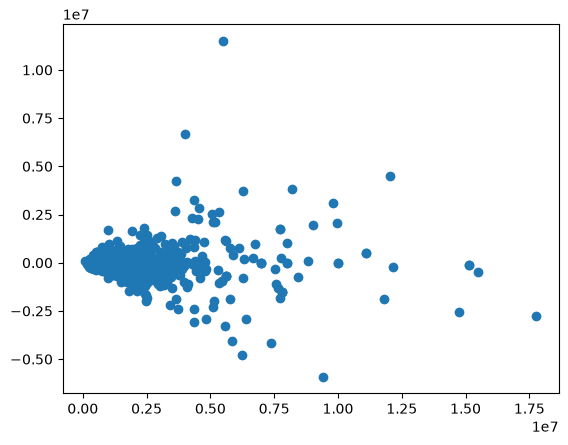

In [23]:
import matplotlib.pyplot as plt

plt.scatter(x=y_pred, y=(y_test-y_pred))
plt.show()